In [55]:
import torch
from calibr_polar import *
import copy
import matplotlib.pyplot as plt

In [2]:
if torch.cuda.is_available():
    device = torch.device('cuda')
    print("Using GPU")
else:   
    device = torch.device('cpu')
    print("Using CPU")

Using CPU


In [765]:
res1, res2, res3, res4, res5, res6 = extract_calibr('Z:\\DATA\\4polar_data\\2025-12-16 -calibr_polar_classic_graduations_down\\Calib_Polar_2025-12-16_0\\images\\RAW_DATA\\image_Pos0.ome.tif')

<tifffile.read_micromanager_metadata> failed to read index map, raised ValueError('invalid header')
<tifffile.read_micromanager_metadata> failed to read display settings, raised ValueError('invalid display_header 0')
<tifffile.read_micromanager_metadata> failed to read index map, raised ValueError('invalid header')
<tifffile.read_micromanager_metadata> failed to read display settings, raised ValueError('invalid display_header 0')
<tifffile.read_micromanager_metadata> failed to read index map, raised ValueError('invalid header')
<tifffile.read_micromanager_metadata> failed to read display settings, raised ValueError('invalid display_header 0')
<tifffile.read_micromanager_metadata> failed to read index map, raised ValueError('invalid header')
<tifffile.read_micromanager_metadata> failed to read display settings, raised ValueError('invalid display_header 0')
<tifffile.read_micromanager_metadata> failed to read index map, raised ValueError('invalid header')
<tifffile.read_micromanager_meta

In [766]:
zer = zero('Z:\\DATA\\4polar_data\\2025-12-16 -calibr_polar_classic_graduations_down\\Calib_Polar_2025-12-16_0\\images\\RAW_DATA\\image_Pos0.ome.tif')

<tifffile.read_micromanager_metadata> failed to read index map, raised ValueError('invalid header')
<tifffile.read_micromanager_metadata> failed to read display settings, raised ValueError('invalid display_header 0')


In [767]:
intensity = open_ome('\\\\NAS_LOCCO\\Amaury\\DATA\\4polar_data\\PolMFM_SilicaBeads_SLB_NR\\Calibration\\Calib-Intensity_NoPolar_TL3D_filter617nm\\Calib_Polar_2024-01-11\\images\\RAW_DATA\\image_Pos0.ome.tif')

<tifffile.read_micromanager_metadata> failed to read index map, raised ValueError('invalid header')
<tifffile.read_micromanager_metadata> failed to read display settings, raised ValueError('invalid display_header 0')


In [768]:
i1, i2, i3, i4, i5, i6 = extract_sqr(intensity)

In [769]:
i1-=zer
i2-=zer
i3-=zer
i4-=zer
i5-=zer
i6-=zer

In [770]:
res1-=zer
res2-=zer
res3-=zer
res4-=zer
res5-=zer
res6-=zer

In [771]:
res1/=i1
res2/=i2
res3/=i3
res4/=i4
res5/=i5
res6/=i6

In [772]:
res1 = np.roll(np.roll(res1, 36-21), 18)
res2 = np.roll(np.roll(res2, 36-21), 18)
res3 = np.roll(np.roll(res3, 36-21), 18)
res4 = np.roll(np.roll(res4, 36-21), 18)
res5 = np.roll(np.roll(res5, 36-21), 18)
res6 = np.roll(np.roll(res6, 36-21), 18)

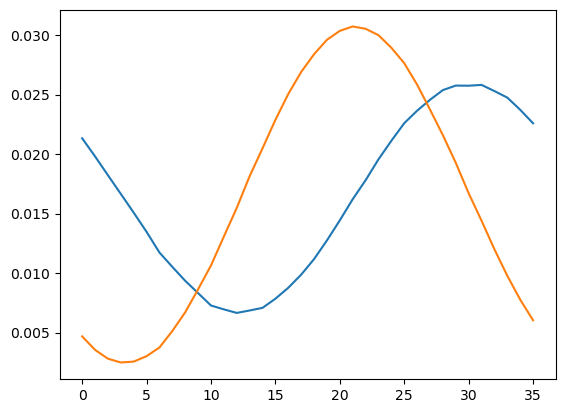

In [773]:
plt.plot(res1)
#plt.plot(res2)
plt.plot(res3)
#plt.plot(res4)
#plt.plot(res5)
#plt.plot(res6)

In [794]:
a1 = 1.
b1 = 0.001
b2 = 0.001
c1 = 0.001
c2 = 0.001
d1 = 1.
d2 = 0.001

I0 = 1.
offset=0*np.pi/180.
alpha = -21.
alpha_start = copy.deepcopy(alpha)

In [795]:
def through_microscope(I0, a1, b1, b2, c1, c2, d1, d2, alpha, offset):
    J = torch.stack([
        torch.stack([a1, b1 + 1j*b2]),
        torch.stack([c1 + 1j*c2, d1 + 1j*d2])
    ]
    ).to(torch.complex128)
    phii = torch.linspace(0, np.pi, 36)+offset
    input_ = I0*torch.stack([torch.cos(phii), torch.sin(phii)]).to(device).to(torch.complex128)
    output_ = torch.einsum('ab,bc->ac', J, input_)
    output_2 =  rotation(alpha, output_)
    return (output_[0]*torch.conj(output_[0])).to(torch.float64), (output_[1]*torch.conj(output_[1])).to(torch.float64), (output_2[0]*torch.conj(output_2[0])).to(torch.float64), (output_2[1]*torch.conj(output_2[1])).to(torch.float64)

In [796]:
def rotation(alpha, inp): # input is a vector Ex, Ey
    alpha = alpha*torch.pi/180
    Rot = torch.stack([
        torch.stack([torch.cos(alpha), -torch.sin(alpha)]),
        torch.stack([torch.sin(alpha),torch.cos(alpha)])
    ]).to(torch.complex128)
    lambda_2 = torch.tensor([
    [1., 0.],
    [0., -1.]
    ]).to(torch.complex128)
    final = torch.einsum('ab,bc->ac', Rot, torch.einsum('ab,bc->ac', lambda_2, torch.inverse(Rot)))
    return torch.einsum('ab,bc->ac', final, inp)

In [797]:
res1 = torch.tensor(res1, device=device)
res2 = torch.tensor(res2, device=device)
res3 = torch.tensor(res3, device=device)
res4 = torch.tensor(res4, device=device)
res5 = torch.tensor(res5, device=device)
res6 = torch.tensor(res6, device=device)

C:\Users\LOCCO_Louise\AppData\Local\Temp\ipykernel_17676\1781850405.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  res1 = torch.tensor(res1, device=device)
C:\Users\LOCCO_Louise\AppData\Local\Temp\ipykernel_17676\1781850405.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  res2 = torch.tensor(res2, device=device)
C:\Users\LOCCO_Louise\AppData\Local\Temp\ipykernel_17676\1781850405.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  res3 = torch.tensor(res3, device=device)
C:\Users\LOCCO_Louise\AppData\Local\Temp\ipykernel_17676\1781

In [813]:
params = torch.tensor([I0, a1, b1, b2, c1, c2, d1, d2, alpha], device=device)
params.requires_grad=True
optimizer = torch.optim.Adam([params], lr=.5)
loss_ = []

In [814]:
def loss_f(para):
    I0, a1, b1, b2, c1, c2, d1, d2, alpha = para[0], para[1], para[2], para[3], para[4], para[5], para[6], para[7] , para[8]
    th1, th2, th3, th4 = through_microscope(I0, a1, b1, b2, c1, c2, d1, d2, alpha, offset) 
    J = torch.stack([
        torch.stack([a1, b1 + 1j*b2]),
        torch.stack([c1 + 1j*c2, d1 + 1j*d2])
    ]
    ).to(torch.complex128)
    force_angle = ((alpha-alpha_start)**2)/1000
    force_unitary = 0.0001*torch.sum(torch.abs((torch.einsum('ab, bc-> ac', torch.transpose(torch.conj(J), 0, 1), J)-torch.ones(2))**2))
    return torch.sum((th1-res1)**2)+torch.sum((th2-res2)**2) + torch.sum((th3-res3)**2)+torch.sum((th4-res4)**2) + (I0-torch.abs(I0))**2 + (a1-torch.abs(a1))**2 + (d1-torch.abs(d1))**2 + force_angle + force_unitary

In [815]:
for i in range(4000):
    optimizer.zero_grad()
    loss=loss_f(params)
    loss.backward()  # Backpropagation
    optimizer.step()
    loss_.append(loss.detach().numpy())

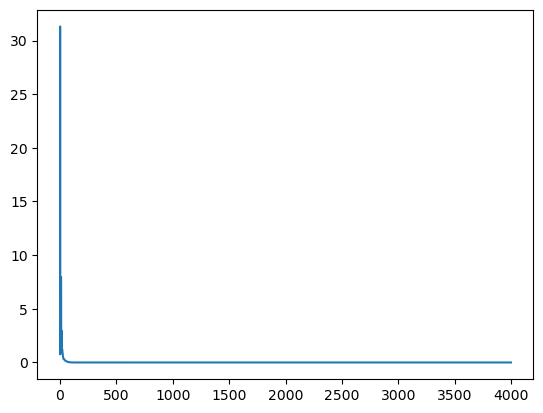

In [816]:
plt.plot(loss_)

In [817]:
print('I0 = ', params[0].detach().numpy())
print('J = ', params[1].detach().numpy(), '                   ', params[2].detach().numpy(), '+ i ', params[3].detach().numpy())
print('     ', params[4].detach().numpy(), '+ i ', params[5].detach().numpy(), '   ', params[6].detach().numpy(), '+ i ', params[7].detach().numpy())
print('angle : ', params[8].detach().numpy())
#print('offset : ', params[9].detach().numpy()*180/np.pi)

I0 =  0.5571265
J =  0.2646684                     -0.08827579 + i  0.15587579
      0.15437593 + i  0.084718674     0.23629372 + i  -0.13453841
angle :  -20.988722


In [818]:
I0, a1, b1, b2, c1, c2, d1, d2, alpha = params[0], params[1], params[2], params[3], params[4], params[5], params[6], params[7] , params[8]
J = torch.stack([
        torch.stack([a1, b1 + 1j*b2]),
        torch.stack([c1 + 1j*c2, d1 + 1j*d2])
    ]
    ).to(torch.complex128)
force_unitary = torch.sum(torch.abs((torch.einsum('ab, bc-> ac', torch.transpose(torch.conj(J), 0, 1), J)-torch.ones(2))**2))
print(force_unitary)

tensor(3.6004, dtype=torch.float64, grad_fn=<SumBackward0>)


In [819]:
predicted1, predicted2, predicted3, predicted4 = through_microscope(params[0], params[1], params[2], params[3], params[4], params[5], params[6], params[7], params[8], offset)
predicted1 = predicted1.detach().numpy()
predicted2 = predicted2.detach().numpy()
predicted3 = predicted3.detach().numpy()
predicted4 = predicted4.detach().numpy()

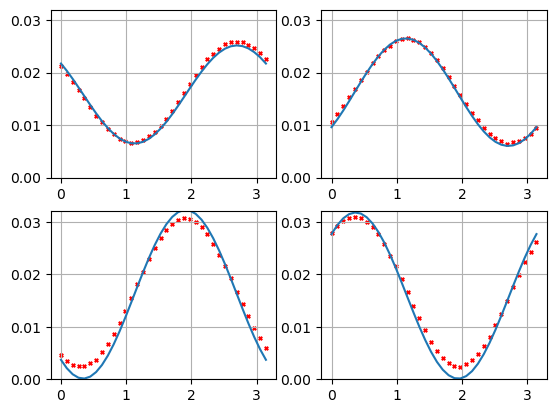

In [820]:
fig, ax = plt.subplots(2,2)
phi = np.linspace(0, np.pi, 36)+offset
ax[0,0].plot(phi, predicted1)
ax[0,0].scatter(phi, res1, c='r', marker='x', s=6)
ax[0,0].set_ylim((0., 0.032))
ax[0,0].grid()
ax[0,1].plot(phi, predicted2)
ax[0,1].scatter(phi, res2, c='r', marker='x', s=6)
ax[0,1].set_ylim((0., 0.032))
ax[0,1].grid()
ax[1,0].plot(phi, predicted3)
ax[1,0].scatter(phi, res3, c='r', marker='x', s=6)
ax[1,0].set_ylim((0., 0.032))
ax[1,0].grid()
ax[1,1].plot(phi, predicted4)
ax[1,1].scatter(phi, res4, c='r', marker='x', s=6)
ax[1,1].set_ylim((0., 0.032))
ax[1,1].grid()

# Calibration after grating

In [747]:
res1, res2, res3, res4, res5, res6 = extract_calibr('Z:\\DATA\\4polar_data\\2025-12-16 - calibration_polarizeur_after_grating_graduations_microscope_side\\Calib_Polar_2025-12-16_0\\images\\RAW_DATA\\image_Pos0.ome.tif')

<tifffile.read_micromanager_metadata> failed to read index map, raised ValueError('invalid header')
<tifffile.read_micromanager_metadata> failed to read display settings, raised ValueError('invalid display_header 0')
<tifffile.read_micromanager_metadata> failed to read index map, raised ValueError('invalid header')
<tifffile.read_micromanager_metadata> failed to read display settings, raised ValueError('invalid display_header 0')
<tifffile.read_micromanager_metadata> failed to read index map, raised ValueError('invalid header')
<tifffile.read_micromanager_metadata> failed to read display settings, raised ValueError('invalid display_header 0')
<tifffile.read_micromanager_metadata> failed to read index map, raised ValueError('invalid header')
<tifffile.read_micromanager_metadata> failed to read display settings, raised ValueError('invalid display_header 0')
<tifffile.read_micromanager_metadata> failed to read index map, raised ValueError('invalid header')
<tifffile.read_micromanager_meta

In [748]:
zer = zero('Z:\\DATA\\4polar_data\\2025-12-16 - calibration_polarizeur_after_grating_graduations_microscope_side\\Calib_Polar_2025-12-16_0\\images\\RAW_DATA\\image_Pos0.ome.tif')
res1-=zer
res2-=zer
res3-=zer
res4-=zer
res5-=zer
res6-=zer

<tifffile.read_micromanager_metadata> failed to read index map, raised ValueError('invalid header')
<tifffile.read_micromanager_metadata> failed to read display settings, raised ValueError('invalid display_header 0')


In [749]:
res1/=i1
res2/=i2
res3/=i3
res4/=i4
res5/=i5
res6/=i6

In [750]:
phi = np.linspace(0, np.pi, 36)

In [751]:
np.argmax(res1)

np.int64(21)

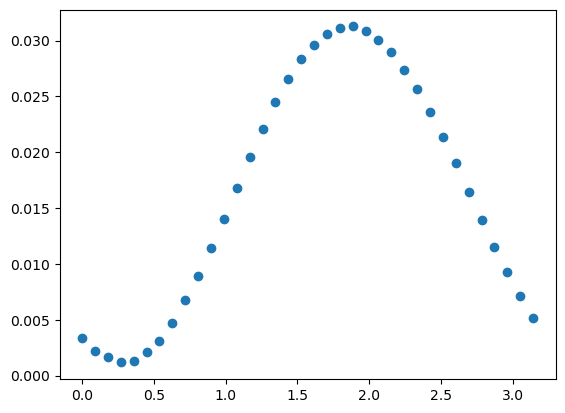

In [752]:
plt.scatter(phi, res1)

In [753]:
res1 = np.roll(res1, 36-21)[::-1]
res2 = np.roll(res2, 36-21)[::-1]
res3 = np.roll(res3, 36-21)[::-1]
res4 = np.roll(res4, 36-21)[::-1]
res5 = np.roll(res5, 36-21)[::-1]
res6 = np.roll(res6, 36-21)[::-1]

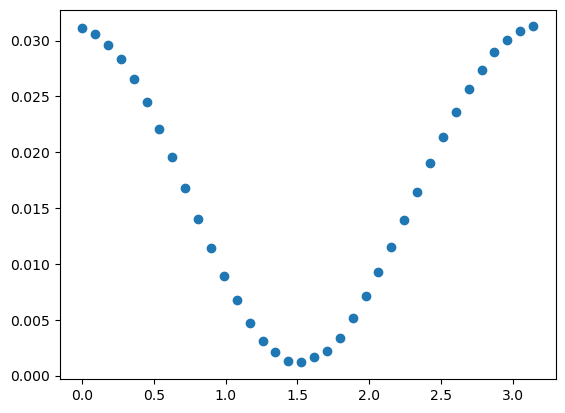

In [754]:
plt.scatter(phi, res1)

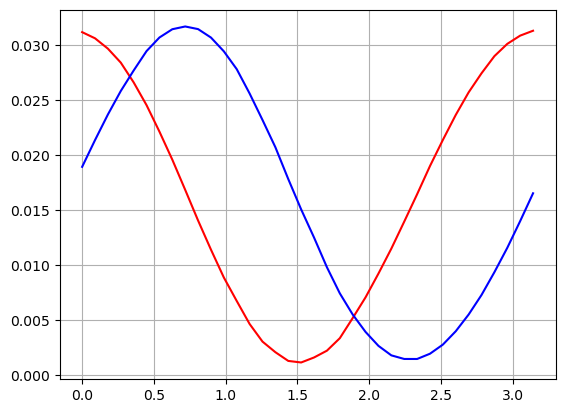

In [755]:
plt.plot(phi, res1, c='r')
#plt.plot(phi, res2, c='g')
plt.plot(phi, res3, c='b')
#plt.plot(phi, res4, c='y')
#plt.plot(phi, res5)
#plt.plot(phi, res6)
plt.grid()

In [756]:
res1 = torch.tensor(res1.copy(), device=device)
res2 = torch.tensor(res2.copy(), device=device)
res3 = torch.tensor(res3.copy(), device=device)
res4 = torch.tensor(res4.copy(), device=device)
res5 = torch.tensor(res5.copy(), device=device)
res6 = torch.tensor(res6.copy(), device=device)

In [757]:
def through_end_microscope(I0, angle, offset):
    input_ = I0*torch.stack((torch.cos(torch.linspace(0+offset*torch.pi/180, torch.pi+offset*torch.pi/180, 36)), torch.sin(torch.linspace(0+offset*torch.pi/180, torch.pi+offset*np.pi/180, 36)))).to(torch.complex128).to(device)
    output_ = input_
    output_2 =  rotation(angle, output_)
    return (output_[0]*torch.conj(output_[0])).to(torch.float64), (output_[1]*torch.conj(output_[1])).to(torch.float64), (output_2[0]*torch.conj(output_2[0])).to(torch.float64), (output_2[1]*torch.conj(output_2[1])).to(torch.float64)

In [758]:
def loss_f2(para):
    I0, angle, offset = para[0], para[1], para[2]
    th1, th2, th3, th4 = through_end_microscope(I0, angle, offset) 
    return torch.sum((th1-res1)**2)+torch.sum((th2-res2)**2) + torch.sum((th3-res3)**2)+torch.sum((th4-res4)**2) + (I0-torch.abs(I0))**2 #+ (offset**2)/1000

In [759]:
params = torch.tensor([0.3, 22.5, 2.], device=device)
params.requires_grad=True
optimizer = torch.optim.Adam([params], lr=1.)
loss_ = []

In [760]:
for i in range(4000):
    optimizer.zero_grad()
    loss=loss_f2(params)
    loss.backward()  # Backpropagation
    optimizer.step()
    loss_.append(loss.detach().numpy())

In [761]:
predicted1, predicted2, predicted3, predicted4 = through_end_microscope(params[0], params[1], params[2])
predicted1 = predicted1.detach().numpy()
predicted2 = predicted2.detach().numpy()
predicted3 = predicted3.detach().numpy()
predicted4 = predicted4.detach().numpy()

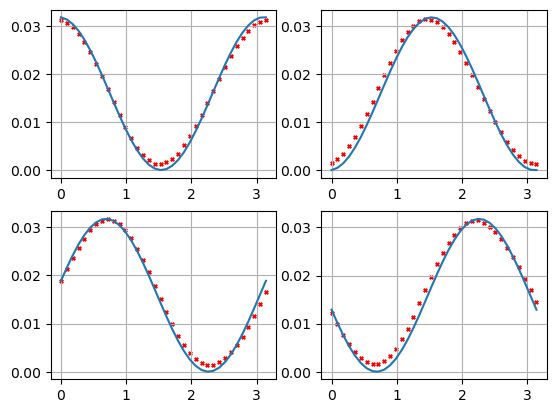

In [762]:
fig, ax = plt.subplots(2,2)
#phi1 = np.linspace(0+params[2].detach().numpy()*np.pi/180, np.pi+params[2].detach().numpy()*np.pi/180, 36)
phi2 = np.linspace(0, np.pi, 36)
phi1=phi2
ax[0,0].plot(phi1, predicted1)
ax[0,0].scatter(phi2, res1, c='r', marker='x', s=6)
ax[0,0].grid()
ax[0,1].plot(phi1, predicted2)
ax[0,1].scatter(phi2, res2, c='r', marker='x', s=6)
ax[0,1].grid()
ax[1,0].plot(phi1, predicted3)
ax[1,0].scatter(phi2, res3, c='r', marker='x', s=6)
ax[1,0].grid()
ax[1,1].plot(phi1, predicted4)
ax[1,1].scatter(phi2, res4, c='r', marker='x', s=6)
ax[1,1].grid()

In [763]:
params

tensor([ 0.1783, 20.7870,  2.0000], requires_grad=True)